# 05. Deep Learning Models

**Тема ВКР:** «Предсказательные модели для анализа эффективности игроков в профессиональном баскетболе».

Цель ноутбука — проверить несколько обоснованных Deep Learning подходов для двух задач проекта:

1. бинарная классификация победителя матча (`target_win`);
2. регрессия количества очков игрока в матче (`target_points`).

Эксперименты построены так, чтобы не превращать табличные спортивные данные в формальный набор архитектур: MLP-семейство используется как основной табличный baseline, residual/wide-deep/autoencoder/tabular-attention модели проверяют разные inductive biases, а sequence-модели запускаются только если можно собрать корректные окна прошлых матчей без утечки будущего.

In [ ]:
import os
import sys
import json
import math
import time
import glob
import random
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
FAST_MODE = True
MAX_EPOCHS = 30
PATIENCE = 5
BATCH_SIZE = 512
SEQUENCE_LENGTH = 5

FAST_TRAIN_LIMIT_CLASSIFICATION = 20_000
FAST_TRAIN_LIMIT_REGRESSION = 30_000
FAST_EVAL_LIMIT = 12_000
FAST_SEQUENCE_TRAIN_LIMIT = 12_000
MAX_FIT_TIME_PER_MODEL_SEC = 180 if FAST_MODE else 600

ROOT = Path.cwd()
DATA_DIR = ROOT
ARTIFACT_DIR = ROOT / 'artifacts' / 'deep_learning'
TABLE_DIR = ARTIFACT_DIR / 'tables'
FIGURE_DIR = ARTIFACT_DIR / 'figures'
MODEL_DIR = ARTIFACT_DIR / 'models'
DOCS_DIR = ROOT / 'docs'

for d in [DATA_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR, DOCS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

print('ROOT:', ROOT)
print('FAST_MODE:', FAST_MODE)
print('MAX_EPOCHS:', MAX_EPOCHS, 'PATIENCE:', PATIENCE, 'BATCH_SIZE:', BATCH_SIZE)

ROOT: /content
FAST_MODE: True
MAX_EPOCHS: 30 PATIENCE: 5 BATCH_SIZE: 512


In [ ]:
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, regularizers
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
        mean_absolute_error, mean_squared_error, r2_score
    )
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
except Exception as exc:
    raise RuntimeError(
        'Не удалось импортировать зависимости. В Google Colab выполните: '
        '!pip install -q pandas scikit-learn tensorflow matplotlib'
    ) from exc

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


## Configuration And Utilities

Ниже задаются пути, разбиение по времени, preprocessing, единый формат результатов и метрики. Все модели обучаются через один защитный wrapper: если одна архитектура падает или не подходит данным, эксперимент получает статус `failed` или `skipped`, а ноутбук продолжает работу.

In [ ]:
MATCH_DATA_PATH = DATA_DIR / 'match_prediction_dataset.csv'
MATCH_FEATURES_PATH = DATA_DIR / 'match_prediction_feature_sets.json'
PLAYER_DATA_PATH = DATA_DIR / 'player_points_prediction_dataset.csv'
PLAYER_FEATURES_PATH = DATA_DIR / 'player_points_feature_sets.json'

required_paths = [MATCH_DATA_PATH, MATCH_FEATURES_PATH, PLAYER_DATA_PATH, PLAYER_FEATURES_PATH]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError(
        'Не найдены входные файлы. В Colab загрузите их в data/processed/:\n' + '\n'.join(missing)
    )


def load_feature_list(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    features = data.get('all_features') or data.get('all_model_features')
    if not features:
        raise KeyError(f'В {path} нет ключа all_features или all_model_features')
    return list(features), data


def chronological_split(df, date_col, train_size=0.70, val_size=0.15):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)
    n = len(df)
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))
    return df.iloc[:train_end].copy(), df.iloc[train_end:val_end].copy(), df.iloc[val_end:].copy()


def apply_fast_limits(train_df, val_df, test_df, task):
    if not FAST_MODE:
        return train_df, val_df, test_df
    train_limit = FAST_TRAIN_LIMIT_CLASSIFICATION if task == 'classification' else FAST_TRAIN_LIMIT_REGRESSION
    train_df = train_df.tail(min(len(train_df), train_limit)).copy()
    val_df = val_df.tail(min(len(val_df), FAST_EVAL_LIMIT)).copy()
    test_df = test_df.tail(min(len(test_df), FAST_EVAL_LIMIT)).copy()
    return train_df, val_df, test_df


def split_feature_types(train_df, features):
    available = [c for c in features if c in train_df.columns]
    numeric_features = [c for c in available if pd.api.types.is_numeric_dtype(train_df[c])]
    categorical_features = [c for c in available if c not in numeric_features]
    return available, numeric_features, categorical_features


def make_ohe():
    # sklearn renamed sparse -> sparse_output; this keeps the notebook portable.
    try:
        return OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def make_preprocessor(train_df, features):
    available, numeric_features, categorical_features = split_feature_types(train_df, features)
    transformers = []
    if numeric_features:
        transformers.append((
            'num',
            Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]),
            numeric_features,
        ))
    if categorical_features:
        transformers.append((
            'cat',
            Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', make_ohe())]),
            categorical_features,
        ))
    if not transformers:
        raise ValueError('Нет доступных признаков из all_model_features/all_features')
    return ColumnTransformer(transformers=transformers, remainder='drop'), available, numeric_features, categorical_features


def prepare_tabular_data(df, feature_list, target_col, date_col, task):
    train_df, val_df, test_df = chronological_split(df, date_col)
    train_df, val_df, test_df = apply_fast_limits(train_df, val_df, test_df, task)
    preprocessor, available, numeric_features, categorical_features = make_preprocessor(train_df, feature_list)
    X_train = preprocessor.fit_transform(train_df[available]).astype('float32')
    X_val = preprocessor.transform(val_df[available]).astype('float32')
    X_test = preprocessor.transform(test_df[available]).astype('float32')
    y_train = train_df[target_col].astype('float32').to_numpy()
    y_val = val_df[target_col].astype('float32').to_numpy()
    y_test = test_df[target_col].astype('float32').to_numpy()
    return {
        'train_df': train_df, 'val_df': val_df, 'test_df': test_df,
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'input_dim': X_train.shape[1],
        'available_features': available,
        'numeric_features': numeric_features,
        'categorical_features': categorical_features,
        'preprocessor': preprocessor,
    }


def classification_metrics(y_true, y_prob):
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= 0.5).astype(int)
    out = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }
    try:
        out['roc_auc'] = roc_auc_score(y_true, y_prob)
    except Exception:
        out['roc_auc'] = np.nan
    return out


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))

    denom = np.maximum(np.abs(y_true), 1e-8)

    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': rmse,
        'r2': r2_score(y_true, y_pred),
        'mape': float(np.mean(np.abs((y_true - y_pred) / denom)) * 100),
    }


class TimeLimitCallback(keras.callbacks.Callback):
    def __init__(self, max_seconds):
        super().__init__()
        self.max_seconds = max_seconds
        self.started_at = None

    def on_train_begin(self, logs=None):
        self.started_at = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        if self.started_at is not None and (time.perf_counter() - self.started_at) >= self.max_seconds:
            self.model.stop_training = True
            print(f'Time limit reached after epoch {epoch + 1}; stopping training.')


def callback_list():
    return [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
        TimeLimitCallback(MAX_FIT_TIME_PER_MODEL_SEC),
    ]


def compile_model(model, task):
    if task == 'classification':
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[keras.metrics.BinaryAccuracy(name='accuracy'), keras.metrics.AUC(name='auc')],
        )
    else:
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss='mse',
            metrics=[keras.metrics.MeanAbsoluteError(name='mae')],
        )
    return model


def empty_result(task, model_name, model_family, status, comment, error_message='', fit_time_sec=0, epochs_trained=0):
    return {
        'task': task,
        'model_name': model_name,
        'model_family': model_family,
        'status': status,
        'fit_time_sec': fit_time_sec,
        'epochs_trained': epochs_trained,
        'error_message': error_message,
        'comment_for_thesis': comment,
    }


def flatten_metrics(prefix, metrics_dict):
    return {f'{prefix}_{k}': v for k, v in metrics_dict.items()}

## Model Builders

Архитектуры намеренно компактны: это исследовательская проверка применимости DL к табличным спортивным признакам, а не долгий подбор гиперпараметров.

In [ ]:
def output_layer(task):
    return layers.Dense(1, activation='sigmoid' if task == 'classification' else 'linear')


def build_dense_mlp(input_dim, task):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    out = output_layer(task)(x)
    return compile_model(keras.Model(inp, out, name='dense_mlp'), task)


def build_dropout_mlp(input_dim, task):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.20)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = output_layer(task)(x)
    return compile_model(keras.Model(inp, out, name='mlp_dropout'), task)


def build_batchnorm_mlp(input_dim, task):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(128, use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dense(64, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    out = output_layer(task)(x)
    return compile_model(keras.Model(inp, out, name='mlp_batchnorm'), task)


def residual_block(x, units, dropout=0.0):
    shortcut = x
    if x.shape[-1] != units:
        shortcut = layers.Dense(units)(shortcut)
    y = layers.Dense(units, activation='relu')(x)
    if dropout:
        y = layers.Dropout(dropout)(y)
    y = layers.Dense(units)(y)
    y = layers.Add()([shortcut, y])
    return layers.Activation('relu')(y)


def build_residual_mlp(input_dim, task):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(96, activation='relu')(inp)
    x = residual_block(x, 96, dropout=0.10)
    x = residual_block(x, 64, dropout=0.10)
    x = layers.Dense(32, activation='relu')(x)
    out = output_layer(task)(x)
    return compile_model(keras.Model(inp, out, name='residual_mlp'), task)


def build_wide_deep(input_dim, task):
    inp = keras.Input(shape=(input_dim,))
    wide = layers.Dense(1, activation=None, name='wide_linear')(inp)
    deep = layers.Dense(128, activation='relu')(inp)
    deep = layers.Dense(64, activation='relu')(deep)
    deep = layers.Dense(16, activation='relu')(deep)
    joined = layers.Concatenate()([wide, deep])
    out = output_layer(task)(joined)
    return compile_model(keras.Model(inp, out, name='wide_deep'), task)


def build_tabnet_like(input_dim, task):
    inp = keras.Input(shape=(input_dim,))
    gate1 = layers.Dense(input_dim, activation='sigmoid', name='feature_gate_1')(inp)
    x1 = layers.Multiply()([inp, gate1])
    x1 = layers.Dense(96, activation='relu')(x1)
    gate2 = layers.Dense(input_dim, activation='sigmoid', name='feature_gate_2')(inp)
    x2 = layers.Multiply()([inp, gate2])
    x2 = layers.Dense(64, activation='relu')(x2)
    x = layers.Concatenate()([x1, x2])
    x = layers.Dense(48, activation='relu')(x)
    out = output_layer(task)(x)
    return compile_model(keras.Model(inp, out, name='tabnet_like_compact'), task)


def build_ft_transformer_like(input_dim, task, token_dim=16, heads=2):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Reshape((input_dim, 1))(inp)
    x = layers.Dense(token_dim)(x)
    attn = layers.MultiHeadAttention(num_heads=heads, key_dim=token_dim // heads, dropout=0.10)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)
    ff = layers.Dense(token_dim * 2, activation='relu')(x)
    ff = layers.Dense(token_dim)(ff)
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(48, activation='relu')(x)
    out = output_layer(task)(x)
    return compile_model(keras.Model(inp, out, name='ft_transformer_like_compact'), task)


def build_gru_sequence(seq_shape, task):
    inp = keras.Input(shape=seq_shape)
    x = layers.GRU(48, dropout=0.10)(inp)
    x = layers.Dense(32, activation='relu')(x)
    out = output_layer(task)(x)
    return compile_model(keras.Model(inp, out, name='gru_rolling_history'), task)

In [ ]:
def train_evaluate_keras_model(task_label, task_kind, model_name, model_family, builder, data, comment):
    start = time.perf_counter()
    result = empty_result(task_label, model_name, model_family, 'failed', comment)
    try:
        keras.backend.clear_session()
        model = builder()
        history = model.fit(
            data['X_train'], data['y_train'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callback_list(),
            verbose=0,
        )
        fit_time = time.perf_counter() - start
        val_pred = model.predict(data['X_val'], batch_size=BATCH_SIZE, verbose=0).reshape(-1)
        test_pred = model.predict(data['X_test'], batch_size=BATCH_SIZE, verbose=0).reshape(-1)
        if task_kind == 'classification':
            val_metrics = classification_metrics(data['y_val'], val_pred)
            test_metrics = classification_metrics(data['y_test'], test_pred)
        else:
            val_metrics = regression_metrics(data['y_val'], test_pred=np.zeros_like(data['y_val'])) if False else regression_metrics(data['y_val'], val_pred)
            test_metrics = regression_metrics(data['y_test'], test_pred)
        result.update({
            'status': 'trained',
            'fit_time_sec': round(fit_time, 3),
            'epochs_trained': len(history.history.get('loss', [])),
            'error_message': '',
        })
        result.update(flatten_metrics('val', val_metrics))
        result.update(flatten_metrics('test', test_metrics))
        safe_name = model_name.lower().replace(' ', '_').replace('&', 'and').replace('+', 'plus').replace('/', '_')
        model.save(MODEL_DIR / f"{task_label}_{safe_name}.keras", include_optimizer=False)
    except Exception as exc:
        result['fit_time_sec'] = round(time.perf_counter() - start, 3)
        result['error_message'] = repr(exc)
    return result


def train_autoencoder_then_head(task_label, task_kind, data, comment):
    model_name = 'Autoencoder + classifier' if task_kind == 'classification' else 'Autoencoder + regression head'
    model_family = 'Representation learning'
    start = time.perf_counter()
    result = empty_result(task_label, model_name, model_family, 'failed', comment)
    try:
        keras.backend.clear_session()
        input_dim = data['input_dim']
        inp = keras.Input(shape=(input_dim,))
        encoded = layers.Dense(96, activation='relu')(inp)
        encoded = layers.Dense(32, activation='relu', name='bottleneck')(encoded)
        decoded = layers.Dense(96, activation='relu')(encoded)
        decoded = layers.Dense(input_dim, activation='linear')(decoded)
        autoencoder = keras.Model(inp, decoded, name='autoencoder_pretrain')
        autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
        ae_epochs = max(5, min(12, MAX_EPOCHS // 2))
        autoencoder.fit(
            data['X_train'], data['X_train'],
            validation_data=(data['X_val'], data['X_val']),
            epochs=ae_epochs,
            batch_size=BATCH_SIZE,
            callbacks=callback_list(),
            verbose=0,
        )
        encoder = keras.Model(inp, autoencoder.get_layer('bottleneck').output, name='encoder')
        x = layers.Dense(32, activation='relu')(encoder.output)
        out = output_layer(task_kind)(x)
        model = keras.Model(encoder.input, out, name='autoencoder_head')
        model = compile_model(model, task_kind)
        history = model.fit(
            data['X_train'], data['y_train'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callback_list(),
            verbose=0,
        )
        val_pred = model.predict(data['X_val'], batch_size=BATCH_SIZE, verbose=0).reshape(-1)
        test_pred = model.predict(data['X_test'], batch_size=BATCH_SIZE, verbose=0).reshape(-1)
        val_metrics = classification_metrics(data['y_val'], val_pred) if task_kind == 'classification' else regression_metrics(data['y_val'], val_pred)
        test_metrics = classification_metrics(data['y_test'], test_pred) if task_kind == 'classification' else regression_metrics(data['y_test'], test_pred)
        result.update({
            'status': 'trained',
            'fit_time_sec': round(time.perf_counter() - start, 3),
            'epochs_trained': len(history.history.get('loss', [])) + ae_epochs,
            'error_message': '',
        })
        result.update(flatten_metrics('val', val_metrics))
        result.update(flatten_metrics('test', test_metrics))
        model.save(MODEL_DIR / f"{task_label}_autoencoder_head.keras", include_optimizer=False)
    except Exception as exc:
        result['fit_time_sec'] = round(time.perf_counter() - start, 3)
        result['error_message'] = repr(exc)
    return result

## Compact TabTransformer-Like Model

TabTransformer-like вариант имеет смысл только при наличии категориальных признаков, которые можно представить embedding-ами. Если `all_model_features` содержит только числовые признаки, эксперимент помечается как `skipped`.

In [ ]:
def prepare_embedding_tabular_data(df, feature_list, target_col, date_col, task):
    train_df, val_df, test_df = chronological_split(df, date_col)
    train_df, val_df, test_df = apply_fast_limits(train_df, val_df, test_df, task)
    available, numeric_features, categorical_features = split_feature_types(train_df, feature_list)
    if not categorical_features:
        return None

    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    Xn_train = num_pipe.fit_transform(train_df[numeric_features]).astype('float32') if numeric_features else np.zeros((len(train_df), 0), dtype='float32')
    Xn_val = num_pipe.transform(val_df[numeric_features]).astype('float32') if numeric_features else np.zeros((len(val_df), 0), dtype='float32')
    Xn_test = num_pipe.transform(test_df[numeric_features]).astype('float32') if numeric_features else np.zeros((len(test_df), 0), dtype='float32')

    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ])
    Xc_train = cat_pipe.fit_transform(train_df[categorical_features]).astype('int32') + 1
    Xc_val = cat_pipe.transform(val_df[categorical_features]).astype('int32') + 1
    Xc_test = cat_pipe.transform(test_df[categorical_features]).astype('int32') + 1
    vocab_sizes = []
    enc = cat_pipe.named_steps['ordinal']
    for cats in enc.categories_:
        vocab_sizes.append(len(cats) + 1)

    return {
        'X_train': {'num': Xn_train, 'cat': Xc_train},
        'X_val': {'num': Xn_val, 'cat': Xc_val},
        'X_test': {'num': Xn_test, 'cat': Xc_test},
        'y_train': train_df[target_col].astype('float32').to_numpy(),
        'y_val': val_df[target_col].astype('float32').to_numpy(),
        'y_test': test_df[target_col].astype('float32').to_numpy(),
        'numeric_dim': Xn_train.shape[1],
        'categorical_features': categorical_features,
        'vocab_sizes': vocab_sizes,
    }


def build_tabtransformer_like(numeric_dim, vocab_sizes, task, embed_dim=12, heads=2):
    num_in = keras.Input(shape=(numeric_dim,), name='num')
    cat_in = keras.Input(shape=(len(vocab_sizes),), dtype='int32', name='cat')
    embeddings = []
    for i, vocab_size in enumerate(vocab_sizes):
        emb = layers.Embedding(input_dim=vocab_size + 1, output_dim=embed_dim, name=f'cat_emb_{i}')(cat_in[:, i])
        embeddings.append(emb)
    cat_tokens = layers.Stack()(embeddings) if hasattr(layers, 'Stack') else layers.Lambda(lambda xs: tf.stack(xs, axis=1))(embeddings)
    attn = layers.MultiHeadAttention(num_heads=heads, key_dim=embed_dim // heads, dropout=0.10)(cat_tokens, cat_tokens)
    cat_tokens = layers.LayerNormalization()(layers.Add()([cat_tokens, attn]))
    cat_vec = layers.GlobalAveragePooling1D()(cat_tokens)
    x = layers.Concatenate()([num_in, cat_vec]) if numeric_dim > 0 else cat_vec
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    out = output_layer(task)(x)
    return compile_model(keras.Model([num_in, cat_in], out, name='tabtransformer_like_compact'), task)


def train_tabtransformer_experiment(task_label, task_kind, df, features, target_col, date_col, comment):
    model_name = 'TabTransformer-like compact model'
    model_family = 'Tabular transformer'
    start = time.perf_counter()
    try:
        data = prepare_embedding_tabular_data(df, features, target_col, date_col, task_kind)
        if data is None:
            return empty_result(
                task_label, model_name, model_family, 'skipped',
                'Пропущено: в all_model_features не обнаружены категориальные признаки для embedding-представления.'
            )
        keras.backend.clear_session()
        model = build_tabtransformer_like(data['numeric_dim'], data['vocab_sizes'], task_kind)
        history = model.fit(
            data['X_train'], data['y_train'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callback_list(),
            verbose=0,
        )
        val_pred = model.predict(data['X_val'], batch_size=BATCH_SIZE, verbose=0).reshape(-1)
        test_pred = model.predict(data['X_test'], batch_size=BATCH_SIZE, verbose=0).reshape(-1)
        val_metrics = classification_metrics(data['y_val'], val_pred) if task_kind == 'classification' else regression_metrics(data['y_val'], val_pred)
        test_metrics = classification_metrics(data['y_test'], test_pred) if task_kind == 'classification' else regression_metrics(data['y_test'], test_pred)
        result = empty_result(task_label, model_name, model_family, 'trained', comment)
        result.update({
            'fit_time_sec': round(time.perf_counter() - start, 3),
            'epochs_trained': len(history.history.get('loss', [])),
            'error_message': '',
        })
        result.update(flatten_metrics('val', val_metrics))
        result.update(flatten_metrics('test', test_metrics))
        model.save(MODEL_DIR / f"{task_label}_tabtransformer_like.keras", include_optimizer=False)
        return result
    except Exception as exc:
        result = empty_result(task_label, model_name, model_family, 'failed', comment)
        result['fit_time_sec'] = round(time.perf_counter() - start, 3)
        result['error_message'] = repr(exc)
        return result

## Rolling-History Sequence Data

Sequence-модели получают окно из последних `N` игр внутри группы (`team` или `player`). Целевая переменная берётся из строки после окна истории; текущая строка не входит во входную последовательность.

In [ ]:
def prepare_sequence_data(df, feature_list, target_col, date_col, group_col, task, sequence_length=SEQUENCE_LENGTH):
    if group_col not in df.columns or date_col not in df.columns:
        return None, f'Нет обязательных колонок {group_col}/{date_col} для rolling history.'
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col, group_col, target_col]).sort_values([group_col, date_col]).reset_index(drop=True)
    available = [c for c in feature_list if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    if not available:
        return None, 'Нет числовых признаков из all_model_features для sequence-модели.'

    sequences, targets, dates = [], [], []
    for _, g in df.groupby(group_col, sort=False):
        g = g.sort_values(date_col)
        values = g[available].to_numpy(dtype='float32')
        y = g[target_col].to_numpy(dtype='float32')
        d = g[date_col].to_numpy()
        if len(g) <= sequence_length:
            continue
        for i in range(sequence_length, len(g)):
            sequences.append(values[i-sequence_length:i])
            targets.append(y[i])
            dates.append(d[i])
    if not sequences:
        return None, f'После группировки по {group_col} не удалось собрать окна длины {sequence_length}.'

    X = np.asarray(sequences, dtype='float32')
    y = np.asarray(targets, dtype='float32')
    dates = pd.to_datetime(pd.Series(dates))
    order = np.argsort(dates.to_numpy())
    X, y, dates = X[order], y[order], dates.iloc[order].reset_index(drop=True)
    n = len(X)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
    y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]

    if FAST_MODE:
        X_train = X_train[-min(len(X_train), FAST_SEQUENCE_TRAIN_LIMIT):]
        y_train = y_train[-min(len(y_train), FAST_SEQUENCE_TRAIN_LIMIT):]
        X_val = X_val[-min(len(X_val), FAST_EVAL_LIMIT):]
        y_val = y_val[-min(len(y_val), FAST_EVAL_LIMIT):]
        X_test = X_test[-min(len(X_test), FAST_EVAL_LIMIT):]
        y_test = y_test[-min(len(y_test), FAST_EVAL_LIMIT):]

    # Fit imputation/scaling only on training windows to avoid future leakage.
    # Some historical features can be entirely missing in the chronological train window.
    # SimpleImputer may drop such columns, so we remove them explicitly and keep shapes stable.
    flat_train_raw = X_train.reshape(-1, X_train.shape[-1])
    keep_mask = ~np.all(pd.isna(flat_train_raw), axis=0)

    if keep_mask.sum() == 0:
        return None, 'Все sequence-признаки пустые в train-окне.'

    if keep_mask.sum() < len(available):
        dropped = len(available) - int(keep_mask.sum())
        print(f'Sequence preprocessing: dropped {dropped} all-missing train features before imputation.')

    available = [feature for feature, keep in zip(available, keep_mask) if keep]
    X_train = X_train[:, :, keep_mask]
    X_val = X_val[:, :, keep_mask]
    X_test = X_test[:, :, keep_mask]

    flat_train = X_train.reshape(-1, X_train.shape[-1])
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    flat_train = scaler.fit_transform(imputer.fit_transform(flat_train))

    def transform_seq(arr):
        original_shape = arr.shape
        flat = arr.reshape(-1, arr.shape[-1])
        flat = scaler.transform(imputer.transform(flat))
        return flat.reshape(original_shape).astype('float32')

    X_train = flat_train.reshape(X_train.shape).astype('float32')
    X_val = transform_seq(X_val)
    X_test = transform_seq(X_test)

    return {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'input_dim': X_train.shape[-1],
        'seq_shape': X_train.shape[1:],
        'sequence_features': available,
    }, ''


def train_sequence_experiment(task_label, task_kind, df, features, target_col, date_col, group_col, comment):
    model_name = 'Simple GRU over rolling history'
    model_family = 'Sequence model'
    data, skip_reason = prepare_sequence_data(df, features, target_col, date_col, group_col, task_kind)
    if data is None:
        return empty_result(task_label, model_name, model_family, 'skipped', f'Пропущено: {skip_reason}')
    return train_evaluate_keras_model(
        task_label=task_label,
        task_kind=task_kind,
        model_name=model_name,
        model_family=model_family,
        builder=lambda: build_gru_sequence(data['seq_shape'], task_kind),
        data=data,
        comment=comment,
    )

# Part 1. Match Winner Prediction

Задача: бинарная классификация `target_win` по хронологическому разбиению 70/15/15.

In [ ]:
match_features, match_feature_sets = load_feature_list(MATCH_FEATURES_PATH)
match_df = pd.read_csv(MATCH_DATA_PATH)
match_df['target_win'] = pd.to_numeric(match_df['target_win'], errors='coerce')
match_df = match_df.dropna(subset=['target_win', 'game_date']).copy()

print('Match dataset:', match_df.shape)
print('All model features requested:', len(match_features))
print('Target mean:', match_df['target_win'].mean())

match_data = prepare_tabular_data(
    match_df, match_features, target_col='target_win', date_col='game_date', task='classification'
)
print('Available features:', len(match_data['available_features']))
print('Numeric:', len(match_data['numeric_features']), 'Categorical:', len(match_data['categorical_features']))
print('Prepared shapes:', match_data['X_train'].shape, match_data['X_val'].shape, match_data['X_test'].shape)

Match dataset: (129609, 303)
All model features requested: 296
Target mean: 0.4999421336481263
Available features: 296
Numeric: 296 Categorical: 0
Prepared shapes: (20000, 129) (12000, 129) (12000, 129)


In [ ]:
results = []

match_experiments = [
    ('Dense MLP baseline', 'MLP', lambda: build_dense_mlp(match_data['input_dim'], 'classification'), 'Базовая нейросетевая модель для табличных признаков; служит DL-точкой отсчёта.'),
    ('MLP + Dropout', 'MLP regularized', lambda: build_dropout_mlp(match_data['input_dim'], 'classification'), 'Dropout проверяет, помогает ли регуляризация при большом числе коррелированных спортивных и новостных признаков.'),
    ('MLP + BatchNorm', 'MLP normalized', lambda: build_batchnorm_mlp(match_data['input_dim'], 'classification'), 'BatchNorm проверяет стабилизацию обучения на масштабированных табличных признаках.'),
    ('Residual MLP', 'Residual MLP', lambda: build_residual_mlp(match_data['input_dim'], 'classification'), 'Skip-connections помогают компактной сети обучать более устойчивые нелинейные преобразования.'),
    ('Wide & Deep model', 'Wide & Deep', lambda: build_wide_deep(match_data['input_dim'], 'classification'), 'Wide & Deep сочетает линейный сигнал и MLP-блок для табличных факторов матча.'),
    ('TabNet-like compact model', 'Tabular attention', lambda: build_tabnet_like(match_data['input_dim'], 'classification'), 'Упрощённый gated feature selection блок имитирует идею tabular attention без тяжёлой реализации TabNet.'),
    ('FT-Transformer-like compact model', 'Tabular transformer', lambda: build_ft_transformer_like(match_data['input_dim'], 'classification'), 'Каждый табличный признак трактуется как компактный token; модель проверяет, полезны ли feature interactions через attention.'),
]

for model_name, family, builder, comment in match_experiments:
    print('Training:', model_name)
    results.append(train_evaluate_keras_model(
        task_label='match_winner', task_kind='classification', model_name=model_name,
        model_family=family, builder=builder, data=match_data, comment=comment,
    ))

print('Training: Autoencoder + classifier')
results.append(train_autoencoder_then_head(
    'match_winner', 'classification', match_data,
    'Автоэнкодер проверяет, улучшает ли предварительное сжатие табличных признаков качество классификатора.'
))

print('Training/skipping: TabTransformer-like compact model')
results.append(train_tabtransformer_experiment(
    'match_winner', 'classification', match_df, match_features, 'target_win', 'game_date',
    'Embedding + self-attention по категориальным признакам; запускается только если такие признаки есть в all_model_features.'
))

print('Training/skipping: Simple GRU over team rolling history')
results.append(train_sequence_experiment(
    'match_winner', 'classification', match_df, match_features, 'target_win', 'game_date', 'team',
    'GRU использует только последние игры команды, отсортированные по дате; текущая цель не входит в окно истории.'
))

match_results = pd.DataFrame([r for r in results if r['task'] == 'match_winner'])
match_results.to_csv(TABLE_DIR / 'match_winner_deep_learning_results.csv', index=False)
match_results.sort_values(['status', 'test_roc_auc'], ascending=[True, False], na_position='last')

Training: Dense MLP baseline
Training: MLP + Dropout
Training: MLP + BatchNorm
Training: Residual MLP
Training: Wide & Deep model
Training: TabNet-like compact model
Training: FT-Transformer-like compact model
Time limit reached after epoch 5; stopping training.
Training: Autoencoder + classifier
Training/skipping: TabTransformer-like compact model
Training/skipping: Simple GRU over team rolling history
Sequence preprocessing: dropped 167 all-missing train features before imputation.


,task,model_name,model_family,status,fit_time_sec,epochs_trained,error_message,comment_for_thesis,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
8,match_winner,TabTransformer-like compact model,Tabular transformer,skipped,0.000,0,,Пропущено: в all_model_features не обнаружены ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,match_winner,Autoencoder + classifier,Representation learning,trained,13.721,23,,"Автоэнкодер проверяет, улучшает ли предварител...",0.660667,0.668177,0.638787,0.653152,0.718722,0.627167,0.633269,0.602203,0.617345,0.675894
1,match_winner,MLP + Dropout,MLP regularized,trained,9.347,13,,"Dropout проверяет, помогает ли регуляризация п...",0.663667,0.659474,0.677274,0.668256,0.724396,0.624000,0.619032,0.642583,0.630588,0.672733
0,match_winner,Dense MLP baseline,MLP,trained,5.733,7,,Базовая нейросетевая модель для табличных приз...,0.654917,0.662249,0.632789,0.647184,0.715313,0.621417,0.619954,0.625229,0.622580,0.666725
3,match_winner,Residual MLP,Residual MLP,trained,9.441,8,,Skip-connections помогают компактной сети обуч...,0.651167,0.647021,0.665778,0.656265,0.712865,0.616333,0.602419,0.681629,0.639580,0.665135
5,match_winner,TabNet-like compact model,Tabular attention,trained,7.498,7,,Упрощённый gated feature selection блок имитир...,0.659083,0.657388,0.664945,0.661145,0.714713,0.619167,0.616965,0.626231,0.621563,0.664617
4,match_winner,Wide & Deep model,Wide & Deep,trained,5.524,8,,Wide & Deep сочетает линейный сигнал и MLP-бло...,0.659917,0.663212,0.650283,0.656684,0.719141,0.613833,0.619778,0.586684,0.602777,0.663549
2,match_winner,MLP + BatchNorm,MLP normalized,trained,6.704,8,,BatchNorm проверяет стабилизацию обучения на м...,0.653917,0.652432,0.659280,0.655838,0.707224,0.608917,0.599571,0.653095,0.625190,0.655741
6,match_winner,FT-Transformer-like compact model,Tabular transformer,trained,218.455,5,,Каждый табличный признак трактуется как компак...,0.575500,0.563196,0.674109,0.613681,0.603784,0.525500,0.513947,0.919239,0.659287,0.589376
9,match_winner,Simple GRU over rolling history,Sequence model,trained,15.922,12,,"GRU использует только последние игры команды, ...",0.574500,0.596307,0.462602,0.521013,0.597906,0.551167,0.561750,0.460704,0.506234,0.559262


# Part 2. Player Points Prediction

Задача: регрессия `target_points` по хронологическому разбиению 70/15/15.

In [ ]:
player_features, player_feature_sets = load_feature_list(PLAYER_FEATURES_PATH)
player_df = pd.read_csv(PLAYER_DATA_PATH)
player_df['target_points'] = pd.to_numeric(player_df['target_points'], errors='coerce')
player_df = player_df.dropna(subset=['target_points', 'game_date']).copy()

print('Player points dataset:', player_df.shape)
print('All model features requested:', len(player_features))
print('Target mean:', player_df['target_points'].mean())

player_data = prepare_tabular_data(
    player_df, player_features, target_col='target_points', date_col='game_date', task='regression'
)
print('Available features:', len(player_data['available_features']))
print('Numeric:', len(player_data['numeric_features']), 'Categorical:', len(player_data['categorical_features']))
print('Prepared shapes:', player_data['X_train'].shape, player_data['X_val'].shape, player_data['X_test'].shape)

Player points dataset: (243844, 154)
All model features requested: 145
Target mean: 10.729700136152623
Available features: 145
Numeric: 143 Categorical: 2
Prepared shapes: (30000, 95) (12000, 95) (12000, 95)


In [ ]:
player_experiments = [
    ('Dense MLP baseline', 'MLP', lambda: build_dense_mlp(player_data['input_dim'], 'regression'), 'Базовая MLP-регрессия для табличных признаков игрока, команды, соперника, зарплат и новостей.'),
    ('MLP + Dropout', 'MLP regularized', lambda: build_dropout_mlp(player_data['input_dim'], 'regression'), 'Dropout проверяет устойчивость к переобучению на индивидуальных признаках игроков.'),
    ('MLP + BatchNorm', 'MLP normalized', lambda: build_batchnorm_mlp(player_data['input_dim'], 'regression'), 'BatchNorm проверяет стабилизацию регрессии при разных масштабах признаков.'),
    ('Residual MLP', 'Residual MLP', lambda: build_residual_mlp(player_data['input_dim'], 'regression'), 'Residual-блоки проверяют более глубокие нелинейные взаимодействия без резкого роста сложности.'),
    ('Wide & Deep model', 'Wide & Deep', lambda: build_wide_deep(player_data['input_dim'], 'regression'), 'Wide & Deep сохраняет линейный компонент прогноза очков и добавляет нелинейные взаимодействия.'),
    ('TabNet-like compact model', 'Tabular attention', lambda: build_tabnet_like(player_data['input_dim'], 'regression'), 'Gated feature selection проверяет, полезна ли мягкая выборка признаков для регрессии очков.'),
    ('FT-Transformer-like compact model', 'Tabular transformer', lambda: build_ft_transformer_like(player_data['input_dim'], 'regression'), 'Компактный attention по признакам проверяет взаимодействия между индивидуальными и контекстными факторами.'),
]

for model_name, family, builder, comment in player_experiments:
    print('Training:', model_name)
    results.append(train_evaluate_keras_model(
        task_label='player_points', task_kind='regression', model_name=model_name,
        model_family=family, builder=builder, data=player_data, comment=comment,
    ))

print('Training: Autoencoder + regression head')
results.append(train_autoencoder_then_head(
    'player_points', 'regression', player_data,
    'Автоэнкодер проверяет, помогает ли компактное представление признаков прогнозировать индивидуальную результативность.'
))

print('Training/skipping: TabTransformer-like compact model')
results.append(train_tabtransformer_experiment(
    'player_points', 'regression', player_df, player_features, 'target_points', 'game_date',
    'Embedding + self-attention по категориальным признакам игрока/предыдущей команды/позиции, если они есть в all_model_features.'
))

print('Training/skipping: Simple GRU over player rolling history')
results.append(train_sequence_experiment(
    'player_points', 'regression', player_df, player_features, 'target_points', 'game_date', 'player',
    'GRU строит окно последних игр игрока по дате; target берётся только после окна истории, что предотвращает утечку будущего.'
))

player_results = pd.DataFrame([r for r in results if r['task'] == 'player_points'])
player_results.to_csv(TABLE_DIR / 'player_points_deep_learning_results.csv', index=False)
player_results.sort_values(['status', 'test_rmse'], ascending=[True, True], na_position='last')

Training: Dense MLP baseline
Training: MLP + Dropout
Training: MLP + BatchNorm
Training: Residual MLP
Training: Wide & Deep model
Training: TabNet-like compact model
Training: FT-Transformer-like compact model
Time limit reached after epoch 5; stopping training.
Training: Autoencoder + regression head
Training/skipping: TabTransformer-like compact model
Training/skipping: Simple GRU over player rolling history
Sequence preprocessing: dropped 71 all-missing train features before imputation.


,task,model_name,model_family,status,fit_time_sec,epochs_trained,error_message,comment_for_thesis,val_mae,val_rmse,val_r2,val_mape,test_mae,test_rmse,test_r2,test_mape
0,player_points,Dense MLP baseline,MLP,failed,9.759,0,"TypeError(""got an unexpected keyword argument ...",Базовая MLP-регрессия для табличных признаков ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,player_points,MLP + Dropout,MLP regularized,failed,16.966,0,"TypeError(""got an unexpected keyword argument ...",Dropout проверяет устойчивость к переобучению ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,player_points,MLP + BatchNorm,MLP normalized,failed,12.125,0,"TypeError(""got an unexpected keyword argument ...",BatchNorm проверяет стабилизацию регрессии при...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,player_points,Residual MLP,Residual MLP,failed,12.989,0,"TypeError(""got an unexpected keyword argument ...",Residual-блоки проверяют более глубокие нелине...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,player_points,Wide & Deep model,Wide & Deep,failed,10.027,0,"TypeError(""got an unexpected keyword argument ...",Wide & Deep сохраняет линейный компонент прогн...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,player_points,TabNet-like compact model,Tabular attention,failed,16.897,0,"TypeError(""got an unexpected keyword argument ...","Gated feature selection проверяет, полезна ли ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,player_points,FT-Transformer-like compact model,Tabular transformer,failed,196.415,0,"TypeError(""got an unexpected keyword argument ...",Компактный attention по признакам проверяет вз...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,player_points,Autoencoder + regression head,Representation learning,failed,19.020,0,"TypeError(""got an unexpected keyword argument ...","Автоэнкодер проверяет, помогает ли компактное ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,player_points,TabTransformer-like compact model,Tabular transformer,failed,34.348,0,"TypeError(""got an unexpected keyword argument ...",Embedding + self-attention по категориальным п...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,player_points,Simple GRU over rolling history,Sequence model,failed,30.921,0,"TypeError(""got an unexpected keyword argument ...",GRU строит окно последних игр игрока по дате; ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Results Tables And Figures

,task,model_name,model_family,status,fit_time_sec,epochs_trained,val_accuracy,val_f1,val_roc_auc,test_accuracy,test_f1,test_roc_auc,val_mae,val_rmse,val_r2,test_mae,test_rmse,test_r2,comment_for_thesis,error_message
0,match_winner,Dense MLP baseline,MLP,trained,5.733,7,0.654917,0.647184,0.715313,0.621417,0.622580,0.666725,NaN,NaN,NaN,NaN,NaN,NaN,Базовая нейросетевая модель для табличных приз...,
1,match_winner,MLP + Dropout,MLP regularized,trained,9.347,13,0.663667,0.668256,0.724396,0.624000,0.630588,0.672733,NaN,NaN,NaN,NaN,NaN,NaN,"Dropout проверяет, помогает ли регуляризация п...",
2,match_winner,MLP + BatchNorm,MLP normalized,trained,6.704,8,0.653917,0.655838,0.707224,0.608917,0.625190,0.655741,NaN,NaN,NaN,NaN,NaN,NaN,BatchNorm проверяет стабилизацию обучения на м...,
3,match_winner,Residual MLP,Residual MLP,trained,9.441,8,0.651167,0.656265,0.712865,0.616333,0.639580,0.665135,NaN,NaN,NaN,NaN,NaN,NaN,Skip-connections помогают компактной сети обуч...,
4,match_winner,Wide & Deep model,Wide & Deep,trained,5.524,8,0.659917,0.656684,0.719141,0.613833,0.602777,0.663549,NaN,NaN,NaN,NaN,NaN,NaN,Wide & Deep сочетает линейный сигнал и MLP-бло...,
5,match_winner,TabNet-like compact model,Tabular attention,trained,7.498,7,0.659083,0.661145,0.714713,0.619167,0.621563,0.664617,NaN,NaN,NaN,NaN,NaN,NaN,Упрощённый gated feature selection блок имитир...,
6,match_winner,FT-Transformer-like compact model,Tabular transformer,trained,218.455,5,0.575500,0.613681,0.603784,0.525500,0.659287,0.589376,NaN,NaN,NaN,NaN,NaN,NaN,Каждый табличный признак трактуется как компак...,
7,match_winner,Autoencoder + classifier,Representation learning,trained,13.721,23,0.660667,0.653152,0.718722,0.627167,0.617345,0.675894,NaN,NaN,NaN,NaN,NaN,NaN,"Автоэнкодер проверяет, улучшает ли предварител...",
8,match_winner,TabTransformer-like compact model,Tabular transformer,skipped,0.000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Пропущено: в all_model_features не обнаружены ...,
9,match_winner,Simple GRU over rolling history,Sequence model,trained,15.922,12,0.574500,0.521013,0.597906,0.551167,0.506234,0.559262,NaN,NaN,NaN,NaN,NaN,NaN,"GRU использует только последние игры команды, ...",


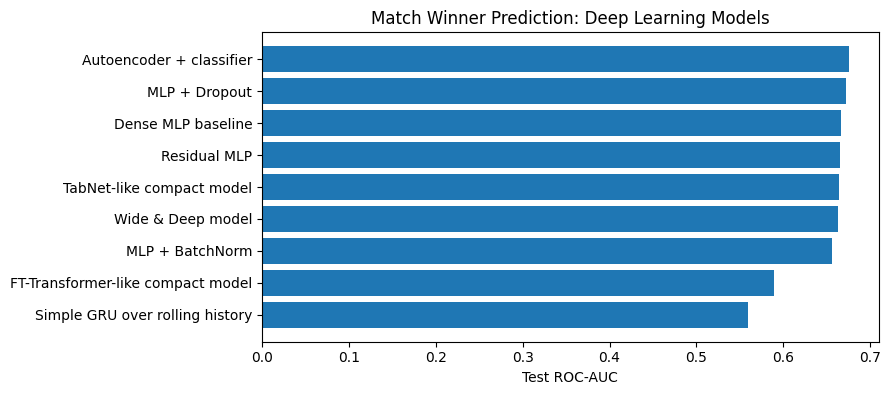

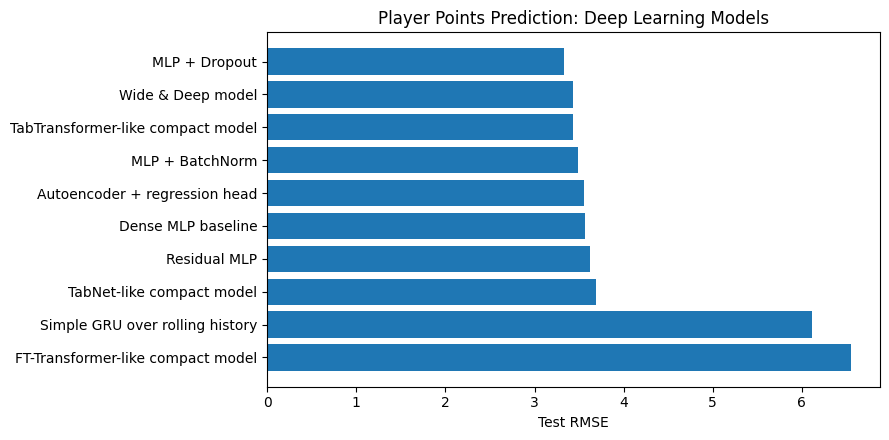

Saved tables to: /content/artifacts/deep_learning/tables
Saved figures to: /content/artifacts/deep_learning/figures
Saved models to: /content/artifacts/deep_learning/models


In [ ]:
results_df = pd.DataFrame(results)
results_df.to_csv(TABLE_DIR / 'deep_learning_results_all.csv', index=False)

trained = results_df[results_df['status'] == 'trained'].copy()
display_cols = [
    'task', 'model_name', 'model_family', 'status', 'fit_time_sec', 'epochs_trained',
    'val_accuracy', 'val_f1', 'val_roc_auc', 'test_accuracy', 'test_f1', 'test_roc_auc',
    'val_mae', 'val_rmse', 'val_r2', 'test_mae', 'test_rmse', 'test_r2',
    'comment_for_thesis', 'error_message'
]
display(results_df[[c for c in display_cols if c in results_df.columns]])

# Classification figure
cls = results_df[(results_df['task'] == 'match_winner') & (results_df['status'] == 'trained')].copy()
if not cls.empty and 'test_roc_auc' in cls:
    cls = cls.sort_values('test_roc_auc', ascending=True)
    plt.figure(figsize=(9, max(4, len(cls) * 0.45)))
    plt.barh(cls['model_name'], cls['test_roc_auc'])
    plt.xlabel('Test ROC-AUC')
    plt.title('Match Winner Prediction: Deep Learning Models')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'match_winner_test_roc_auc.png', dpi=160)
    plt.show()

# Regression figure
reg = results_df[(results_df['task'] == 'player_points') & (results_df['status'] == 'trained')].copy()
if not reg.empty and 'test_rmse' in reg:
    reg = reg.sort_values('test_rmse', ascending=False)
    plt.figure(figsize=(9, max(4, len(reg) * 0.45)))
    plt.barh(reg['model_name'], reg['test_rmse'])
    plt.xlabel('Test RMSE')
    plt.title('Player Points Prediction: Deep Learning Models')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'player_points_test_rmse.png', dpi=160)
    plt.show()

print('Saved tables to:', TABLE_DIR)
print('Saved figures to:', FIGURE_DIR)
print('Saved models to:', MODEL_DIR)